# TODO:
- EDA
- Baseline
- Test more models (justify choices)
- Establish what the company should do with the prediction (inspect machine, replace parts, ignore alert, ...)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(42)

# Exploratory Data Analysis

Let us load the data and check its shape.

In [3]:
train_data = pd.read_csv("data/predictive_maintenance_train.csv")
test_data = pd.read_csv("data/predictive_maintenance_test.csv")

print(train_data.shape)
print(test_data.shape)

(1300, 13)
(350, 13)


The shape of the data corresponds to the expected number of samples and variables in both train and test dataset.

### Target Analysis

Let's begin the EDA by examining the target variable, i.e., whether a machine will encounter a failure within the next 30 days (failure_30d). Since it is a boolean variable, our task naturally lends towards classification.

failure_30d
0    0.866154
1    0.133846
Name: proportion, dtype: float64


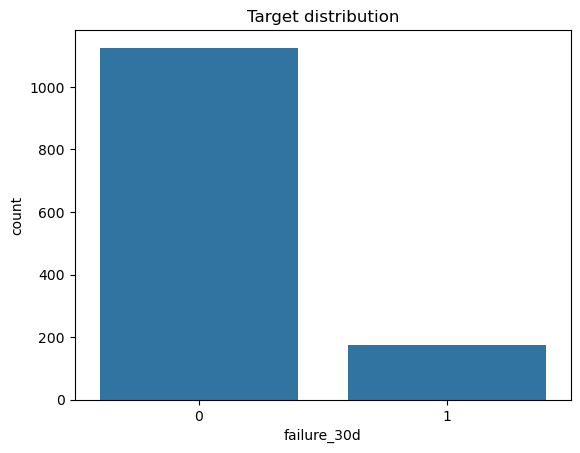

In [4]:
print(train_data["failure_30d"].value_counts(normalize=True))

sns.countplot(data=train_data, x="failure_30d")
plt.title("Target distribution")
plt.show()

From the low frequency of the targeted event in train data, shown by the plot above, we can infer that the event is not likely to happen.

### Features Analysis

Now, let us plot the distribution of each variable to get new information about the variables individually.

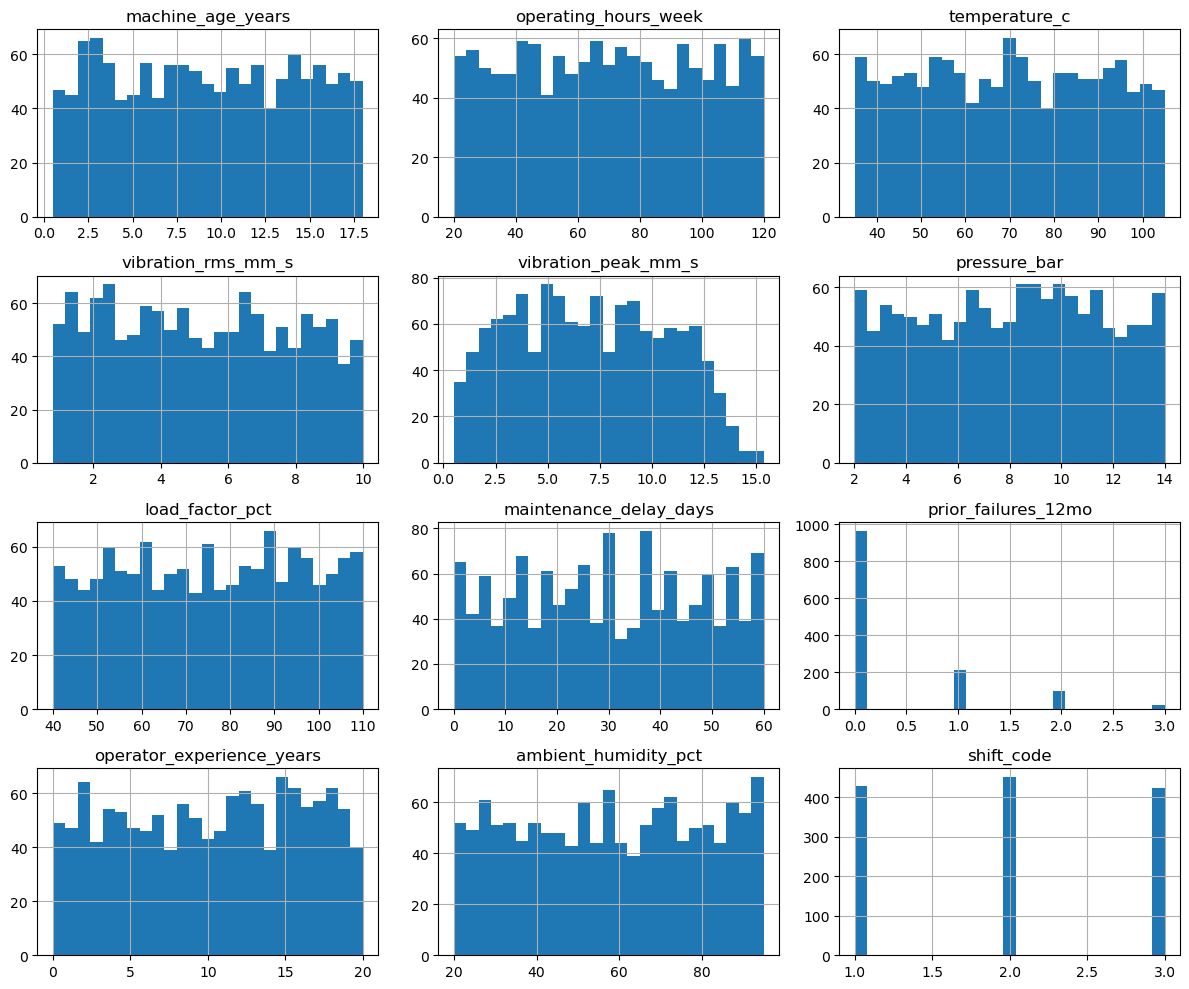

In [5]:
train_data.drop(columns=["failure_30d"]).hist(bins=25, figsize=(12, 10))
plt.tight_layout()
plt.show()

The distribution of the variables do not give us a lot of new information: most of them are approximately uniformly distributed, apart from two exceptions.

The distribution of prior_failures_12mo reinforces our confidence on the fact that a machine having a failure is a rare event: no failure was detected over the last year for most of the machines in the train data.

Also, it reveals that shift_code only take values one, two and three, identifying on which shift the machine was observed. From now on, we will consider this feature as a categorical variable.

Now, let us explore how the variables behave with respect to the failure class. Indeed, it is probable that the machines for which a failure was observed in the next 30 days had technical issues, or were older. Plotting the boxplots by target for each variable will help indentify this kind of behaviour.

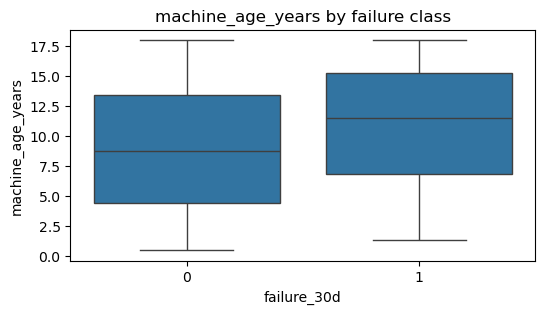

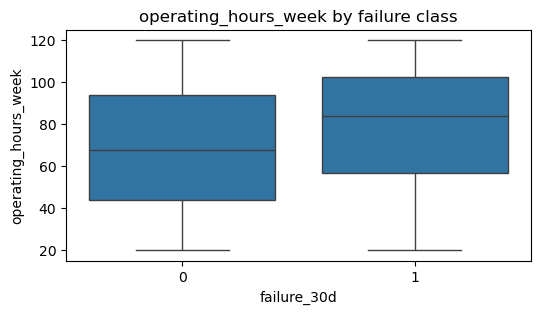

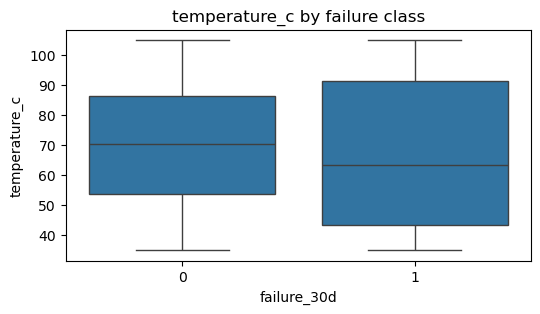

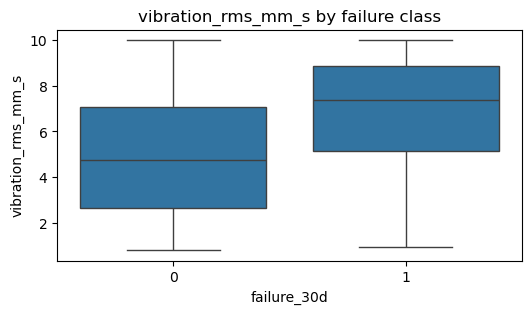

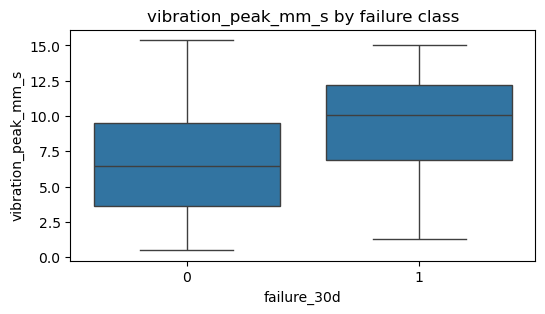

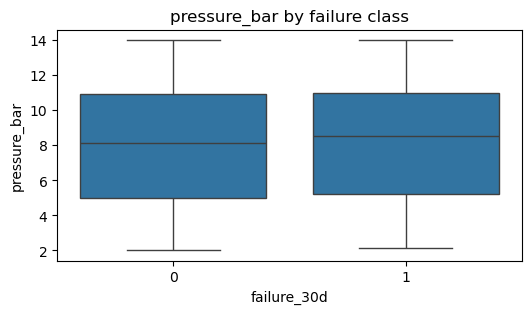

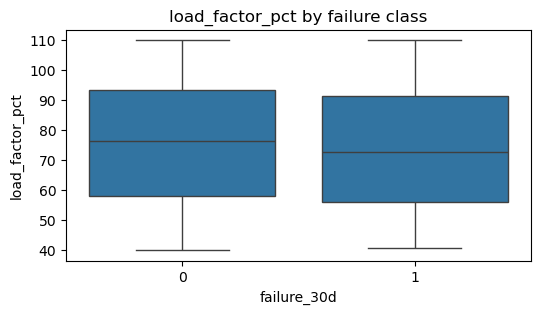

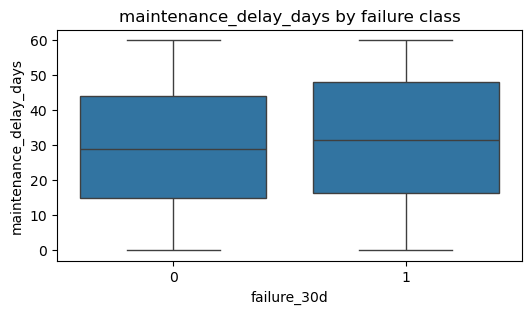

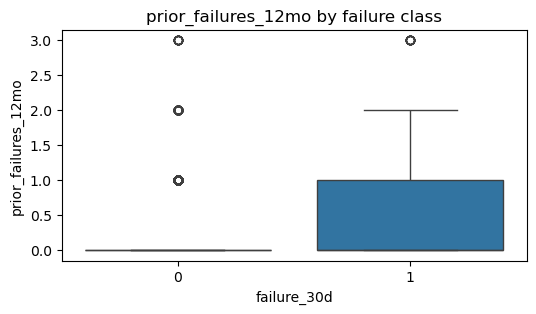

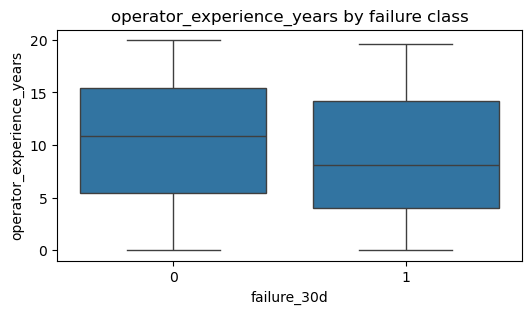

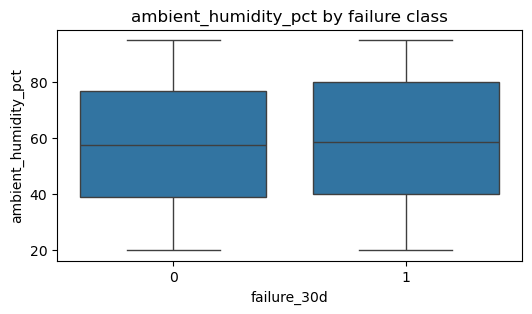

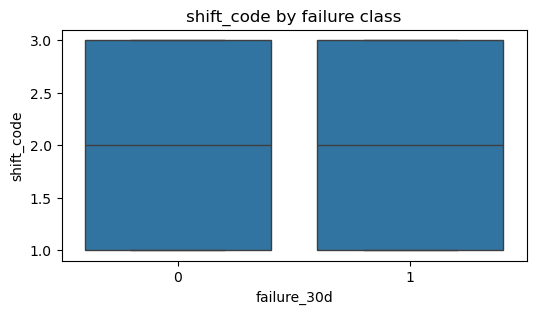

In [6]:
for col in [c for c in train_data.columns if c != "failure_30d"]:
    plt.figure(figsize=(6, 3))
    sns.boxplot(data=train_data, x="failure_30d", y=col)
    plt.title(f"{col} by failure class")
    plt.show()

These plots give us a lot of knowledge about the behavior of the failure state!



For the following variables, we can see clear differences between failure cases: machine_age_years, operating_hours_week, temperature_c (wider range), prior_failure, vibration_peak_mm_s and vibration_rms_mm_s. They seem to be the most impactful features.
Note that other features such as operator_experience_years aloso seem to have an impact on the target, but a much lower one.

### Correlation between features

Now that we have an idea of the impact of the features on failure state, let's explore how features interact with each other. That is, investigate how correlated features are to each other, by computing the feature correlation matrix.

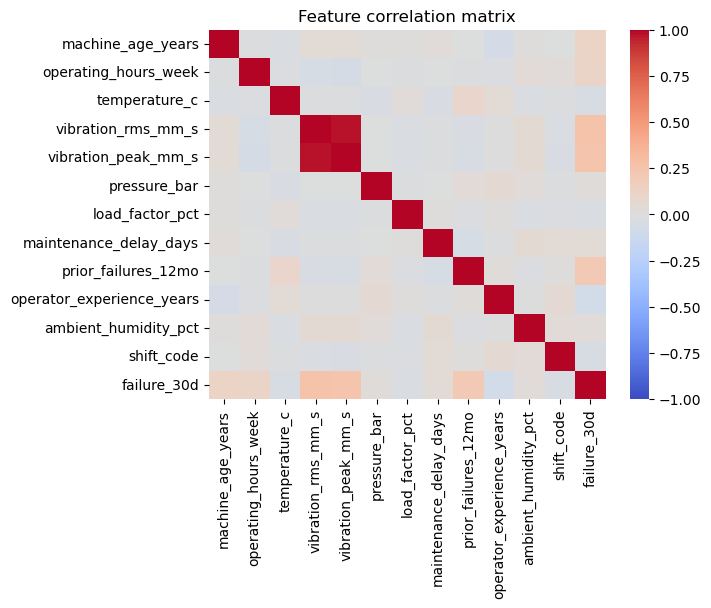

In [7]:
corr = train_data.corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Feature correlation matrix")
plt.show()

The correlation matrix above bring us new knowledge about the correlation between variables.

First, vibration_rms_s and vibration_peak_mm_s are positively correlated (correlation coefficient close to 1). It follows from the fact that both measures are very similar: they both measure vibrations, and clearly the average vibration and the vibration peak are linked to each other: higher the mean, higher the peak. Thus, to avoid redundancy, we could think about removing one of the vibration variables.

Furthermore, it is key to mention the three features that are the most correlated with the target, i.e., the features with a correlation coefficient closest to 1 with respect to the target. These features are the ones regarding vibration observations and previous failures observed over the last year. Note that machine_age_years and operating_hours_week also have a positive correlation coefficient with respect to the target. That is another indicator, on top of the individual boxplots by target, that lead us to say that these four features are the most impactful regarding a future failure of the machine.

Finally, there seem to be an association between operator experience and failure. It could follow from the fact that the more experience an operator has, the less the machine is prone to fail. Note that the prior failures observed over the last 12 months do not seem to be as correlated to the operator's experience as the target.

#### Recap
To put it in a nutshell, the exploratory data analysis shows that the target variable is imbalanced, with failures occuring in only a small proportion of the training data. Moreover, the boxplots and the correlation matrix both suggest that variables such as machine age, operating hours, vibration measures and prior failures are the most impactful for distinguishing failure cases. The correlation analysis also revealed that the two vibration features are strongly related, which may introduce redundancy in the model.

Warning:
- keep an eye on scaling, it can be necessary for some models

# Modeling

see logistic regression / tree-based models (decision tree maybe, but not sure)